## Outline











- Business-case introduction - Healthyfi.me
- Basic EDA

- Parameter Initialisation
- Model Compilation
  1.   Loss

  2.   Optimiser
  3.   Metrics
 - Model Training
  1. X_train, y_train
  2. epochs
  3. batch_size
  4. validation_split
  5. validation_data
- history
  1. verbose
  2. history object attributes
  3. Loss and Accuracy Curve
- Keras Functional API
  1. Why Functional API
  2. Keras Functional Model Class
 - prediction and evaluation
  1. model.evaluate
  2. model.predict

- Callbacks
  1. Why do we need a callback?
  2. Custom callback
  3. Standard callbacks and their purpose
  - Tensorboard
  1.  CallBack
  2. Dashboard


## Business-use case


#### You are a Data Scientist working for Healthyfi.me

Healthyfi.me has labelled it's customers based on the highest intensity of work they could perform - A, B, C and D

#### Task: Given a new customer, help Healthyfi.me in recommending  customised workout plans by predicting customer's class




## Data Acquisition

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

- Lets first download the HealthyfiMe dataset.

In [ ]:
!wget "https://drive.google.com/uc?export=download&id=1GVhrh2rH6hUunV4Tf7lQoSFsqov9aPjU" -O healthyfime.csv

--2023-07-10 14:50:23--  https://drive.google.com/uc?export=download&id=1GVhrh2rH6hUunV4Tf7lQoSFsqov9aPjU
Resolving drive.google.com (drive.google.com)... 172.253.62.102, 172.253.62.101, 172.253.62.100, ...
Connecting to drive.google.com (drive.google.com)|172.253.62.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://doc-0s-50-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/fkaq3krac7j862g0jr444ogaib4tb15a/1689000600000/01388099838663554274/*/1GVhrh2rH6hUunV4Tf7lQoSFsqov9aPjU?e=download&uuid=5c93111a-b742-4453-af56-afbeff617f1c [following]
--2023-07-10 14:50:24--  https://doc-0s-50-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/fkaq3krac7j862g0jr444ogaib4tb15a/1689000600000/01388099838663554274/*/1GVhrh2rH6hUunV4Tf7lQoSFsqov9aPjU?e=download&uuid=5c93111a-b742-4453-af56-afbeff617f1c
Resolving doc-0s-50-docs.googleusercontent.com (doc-0s-50-docs.googleusercontent.com)... 172.253.115.132, 2607

**Data Description:**


| Id | Features | Description |
| :-- | :--| :--|
|01| **age** | age of the customer|
|02| **gender** | gender of the customer (M/F)|
|03|**height_cm**|height of the customer in cm|
|04|**weight_kg**|weight of the customer in kg|
|05|**body_fat_%**| % of fat in customer's body|
|06|**diastolic**|diastolic blood pressure, measures the pressure in your arteries when your heart rests between beats|
|07|**systolic**|systolic blood pressure, measures the pressure in your arteries when your heart beats|
|08|**gripForce**|strength of customer's grip|
|09|**sit and bend forward_cm**|to measure flexibility of customer|
|10|**sit-ups counts**|count of sit-ups customer can perform|
|11|**broad jump_cm**|It is the max jump customer can perform in cm|
|12|**class**|Category of customer based on the intensity of workout|

In [ ]:
df = pd.read_csv("healthyfime.csv")
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


**From the above snippet of data, we can have the following observations:**
- Data has an age column which is definitely required because we need to know what the person's age is in order to predict the class of highest intensity of workout.
- Data has features like 'gender', 'height', 'weight', 'diastolic', etc which we need to know before predicting the workout intensity because think about it we can not predict high intensity workout for a candidate with high blood pressure.
- And in the end there is a class variable where the intensity of workout is encoded to A, B, C and D

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB


####Quiz-1
```
Which observation from the info() of the dataset is correct?
a. There are null values in the dataset.
b. All features consist of numerical values.
c. Some features consist of non-numerical values.
```
Answer: c

## EDA



- Gender has two levels, and class have 4 levels.
- We can easily convert `Gender` to 0/1 labels.
- Since `class` variable is ordinal, we can also replace it with 0, 1, 2, 3. - Can easily use NN.

In [ ]:
df.replace({"M":0, "F":1} , inplace = True)
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


We can also change the name of the classes to numbers, will be easier for us to look at correlations

In [ ]:
classes = list(df['class'].unique())
mapping_dict = { ch : i for i, ch in enumerate(sorted(classes, reverse=True)) }
print (mapping_dict)
df['class'].replace(mapping_dict , inplace = True)
df.head()

{'D': 0, 'C': 1, 'B': 2, 'A': 3}


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,1
1,25.0,0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,3
2,31.0,0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,1
3,32.0,0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,2
4,28.0,0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,2


- We are firstly mapping all the strings to integers in a reversed manner i.e. D is mapped to 0 and A is mapped to 3.
- Then we are replacing all the values in the `class` feature using replace() function and the dictionary we got from the mapping step.

Lets check if there are linear relations across the data

<Axes: >

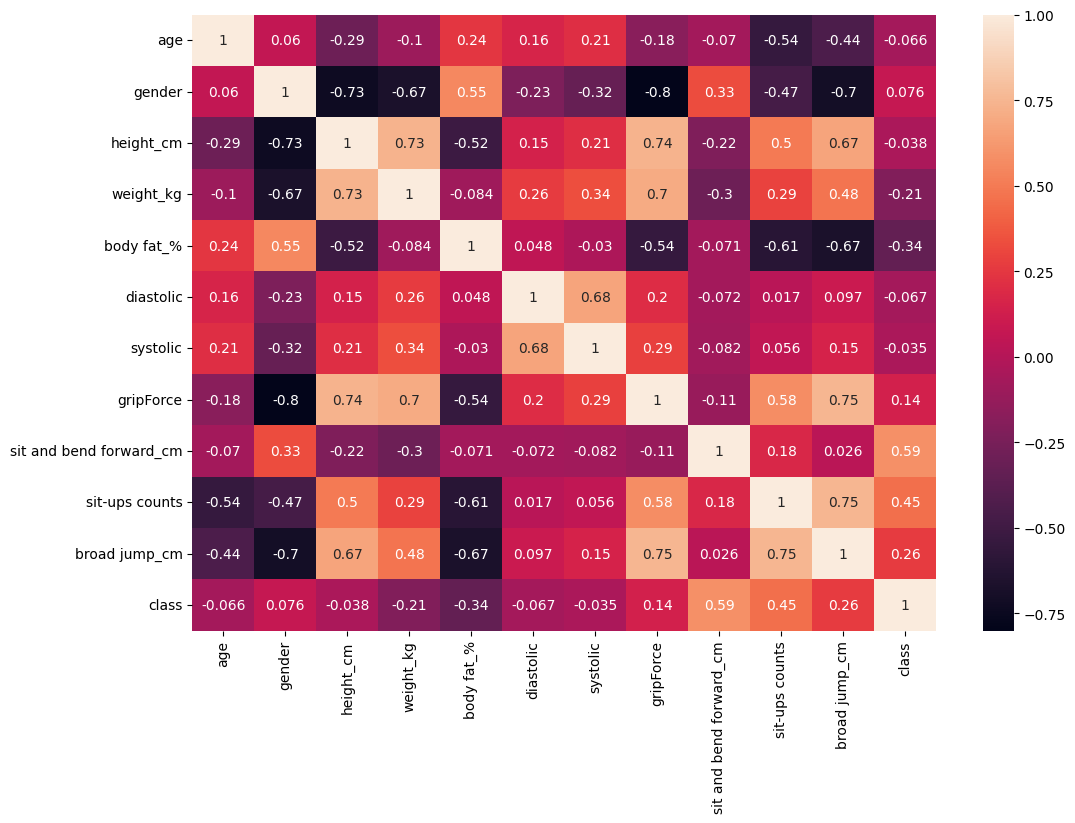

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot = True)

There are no strong linear relationships with `class` variables, which means, there is non-linear relation between `class` and the other variables.

We need to have an understanding of the range and distributions of all the variables. Which plot do you think will be hepful here?


Boxplot

<Axes: >

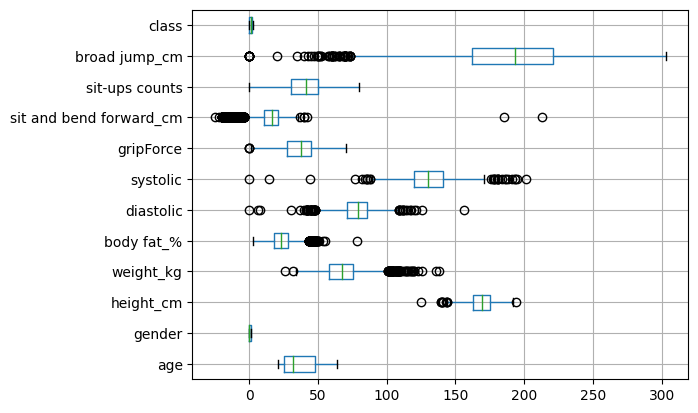

In [ ]:
df.boxplot(rot = 0, vert=False)

The distribution and range of all the features is quite different.

Let's have the independent and dependent variables separated into X and y.

In [ ]:
X, y = df.iloc[:, :-1], df.iloc[:, -1]
print(X.shape, y.shape)

(13393, 11) (13393,)


Now we need to split the data for training and validation

In [ ]:
from sklearn.model_selection import train_test_split

X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.1, random_state=42)

print('Train : ', X_train.shape, y_train.shape)
print('Valid : ', X_val.shape, y_val.shape)
print('Test  : ', X_test.shape, y_test.shape)

Train :  (10847, 11) (10847,)
Valid :  (1206, 11) (1206,)
Test  :  (1340, 11) (1340,)


We have firstly splitted the dataset into dev and test data and then the dev data is further splitted into train and validation data.

Now that our data is prepared to be used for training, lets build the model using Tensorflow

Generally when features are normalized, neural network training is often more efficient


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train,y_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
df

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,1
1,25.0,0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,3
2,31.0,0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,1
3,32.0,0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,2
4,28.0,0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,0,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,1
13389,21.0,0,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,0
13390,39.0,0,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,3
13391,64.0,1,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,0


<Axes: >

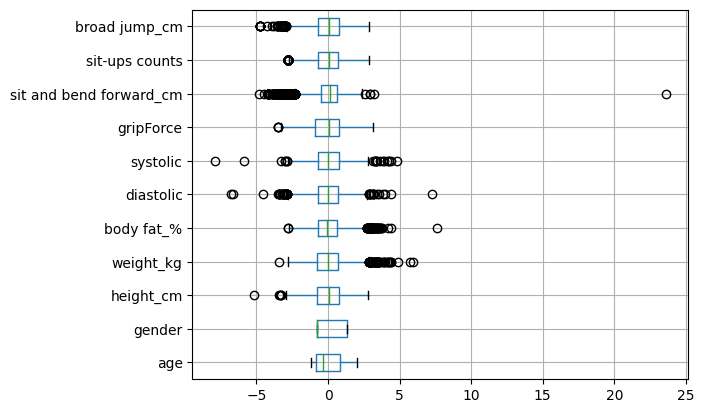

In [ ]:
pd.DataFrame(X_train,columns=df.columns[:-1]).boxplot(rot = 0, vert=False)

Before, we get started, let's explore Tensorflow website a bit
-- --

## Keras Functional API



Look at this complex model

#### Question: Can you design this model using Keras Sequential API ?
- No, there is no way to pass two inputs to one layer in Sequential API
- We use another API of Keras called as Functional API to design such complex models

 <img width=50% src='https://drive.google.com/uc?id=1Gzjwzg9pfJFlewyjMN_0uBiWA7_rKnXT'>


#### Why do we need Functional API instead of Sequential API?

- Functional API gives us **more flexibility**
- This API can handle **multiple inputs and outputs**
- lets say we have an image and a text description as our training data
- Or we want model to output two or more target variables
- Ex- A weather forecast model predicting Min & Max temp at the same time
- Sequential API wont be able to do this

Look at this complex model design, it can not be created using Sequential API but easily by Functional API
- Multiple inputs to one layer
- Multiple outputs of one layer

 <img src='https://drive.google.com/uc?id=1gqeSg6z5ckj6NAS9v011P9c7j8EbG3--'>

- So functional api gives us more **flexibility for network architectures**
- architectures are not always in sequential manner
- we can have two layers in parallel

- It is always recommend to **use the simplest method while building networks**
- Simple models can be easily built with Sequential API
- But sometimes we need the flexibility

In [ ]:
import tensorflow
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

In [ ]:
model_sequential = Sequential([
                    Dense(16, activation="relu", input_shape=(11,), name="hidden_1"),
                    Dense(8, activation="relu", name="hidden_2"),
                    Dense(4, activation="softmax", name="output")
])

- Earlier we have created this model using Sequential API
- Now lets create same model using Functional API

In [ ]:
from tensorflow.keras.layers import Input

- In Sequential we passed input shape in the first layer
- But Here we will be using an additional layer : **Input layer**
- we're going to explicitly have a separate layer to represent the data input.

- Another main diference is `tf.keras.models.Model`
- Here instead of Sequential, here **we will be using Model Class**

### Keras Functional Model Class

- First we create an input layer with the shape of the dataframe

In [ ]:
inp = Input(shape=(11, 1))

- Next we will be creating our first two layer of the model
- Instead of creating a list (as in Sequential)
- We will also pass previous layer in the current layer
- In first dense `hidden_1` we will pass `inp`
- And in second `hidden_1` we will pass `hidden_2`

In [ ]:
h1 = Dense(16, activation="relu", name="hidden_1")(inp)
h2 = Dense(4, activation="relu", name="hidden_2")(h1)

- Now we will create the final output layer

In [ ]:
out = Dense(4, activation="softmax", name="output")(h2)

- We have defined the flow of the model
- Finally,  to built a model using this directed graph
- We will use `tf.keras.models.Model`, and pass all the inputs and outputs

In [ ]:
from tensorflow.keras.models import Model

In [ ]:
model_functional = Model(inputs=inp, outputs=out, name="simple_nn")

Let's generalize above code inside a function

In [ ]:
def create_model_functional():

  inp = Input(shape=(11, 1))

  h1 = Dense(16, activation="relu", name="hidden_1")(inp)
  h2 = Dense(8 , activation="relu", name="hidden_2")(h1)

  out = Dense(4, activation="softmax", name="output")(h2)

  model = Model(inputs=inp, outputs=out, name="simple_nn")
  return model

In [ ]:
model_functional = create_model_functional()

In [ ]:
model_functional.summary()

Model: "simple_nn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 11, 1)]           0         
                                                                 
 hidden_1 (Dense)            (None, 11, 16)            32        
                                                                 
 hidden_2 (Dense)            (None, 11, 8)             136       
                                                                 
 output (Dense)              (None, 11, 4)             36        
                                                                 
Total params: 204
Trainable params: 204
Non-trainable params: 0
_________________________________________________________________


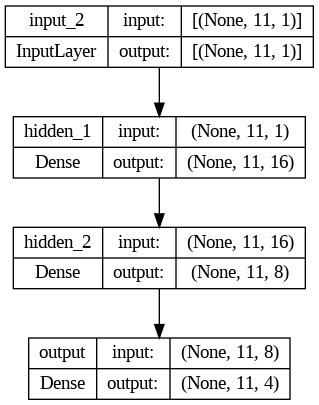

In [ ]:
#And, optionally, display the input and output shapes of each layer in the plotted graph:

tensorflow.keras.utils.plot_model(model_functional,show_shapes=True)

> **<font color='red'>Optional code</font>**


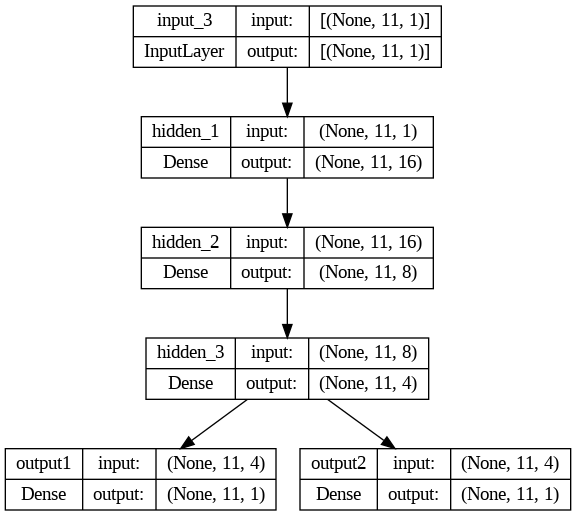

In [ ]:
# let's create a little complex model using functional API's with more than one output

def create_model_multiple_output():
  inp = Input(shape=(11, 1))

  h1 = Dense(16, activation="relu", name="hidden_1")(inp)
  h2 = Dense(8 , activation="relu", name="hidden_2")(h1)
  h3 = Dense(4 , activation="relu", name="hidden_3")(h2)

  out1 = Dense(1, activation="sigmoid", name="output1")(h3)
  out2 = Dense(1, activation="relu", name="output2")(h3)

  model = Model(inputs=inp, outputs=[out1,out2], name="simple_nn")
  return model

# creating model with multiple output
model_multiple_output = create_model_multiple_output()

# plotting model with multiple output
tensorflow.keras.utils.plot_model(model_multiple_output,show_shapes=True)

## Prediction and Evaluation



Lets evaluate the model performance on different sets, we will carry out all predictions using the model created via sequential API

### Evaluate the model

`model.evaluate(X_test, y_test)`

- model.evaluate **returns the loss value & metrics value** for the model.
- It is important to note that, **weights/parameters are not updated during evaluation** (and prediction)
- This also means - **only forward pass, no backward pass**

Now lets evalute our models on training, validation and testing datasets

In [ ]:
model_sequential.compile(optimizer='sgd',loss=tensorflow.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"])

In [ ]:
loss, accuracy = model_sequential.evaluate(X_train, y_train)
print('Train Set')
print("Loss value : ", loss)
print("Accuracy   : ", accuracy)

339/339 [==============================] - 1s 921us/step - loss: 1.5099 - accuracy: 0.2242
Train Set
Loss value :  1.509874701499939
Accuracy   :  0.22420945763587952


In [ ]:
loss, accuracy = model_sequential.evaluate(X_val, y_val)
print('Validation Set')
print("Loss value : ", loss)
print("Accuracy   : ", accuracy)

38/38 [==============================] - 0s 2ms/step - loss: 1.4677 - accuracy: 0.2272
Validation Set
Loss value :  1.4677019119262695
Accuracy   :  0.22719734907150269


In [ ]:
loss, accuracy = model_sequential.evaluate(X_test, y_test)
print('Test Set')
print("Loss value : ", loss)
print("Accuracy   : ", accuracy)

42/42 [==============================] - 0s 2ms/step - loss: 1.5007 - accuracy: 0.1993
Test Set
Loss value :  1.5007195472717285
Accuracy   :  0.19925373792648315


### Predictions

- If we need to get the prediction for an **unseen data**, we can use the `predict` method to get the predictions.
`model.predict(X_test)`

- It **returns raw output** from the model (i.e. **probabilities** of an observation belong to each one of the 4 class)

In [ ]:
pred = model_sequential.predict(X_test)
pred

42/42 [==============================] - 0s 1ms/step


array([[0.3313953 , 0.23238319, 0.08526372, 0.35095784],
       [0.29327518, 0.2360045 , 0.20492265, 0.2657976 ],
       [0.11551967, 0.33723697, 0.10446056, 0.44278285],
       ...,
       [0.2024138 , 0.20204741, 0.14718285, 0.4483559 ],
       [0.17294735, 0.3051341 , 0.18703759, 0.33488098],
       [0.31848285, 0.4779339 , 0.09479942, 0.10878383]], dtype=float32)


####What will be the sum of probabilities of an observation belong to each of the 4 classes?
- 1

- As the model outputs the probabilities for all the observations and each observation can only belong to one of these 4 classes, therefore the sum of probs will be 1.

In [ ]:
np.sum(pred, axis=1)

array([1.0000001, 1.       , 1.       , ..., 1.       , 1.       ,
       1.       ], dtype=float32)

#### How can we know the class an observation belongs to, using these 4 probability values?
We can find the index having the largest probability and that will be the predicted class.

In [ ]:
pred_class = np.argmax(pred, axis = 1)
pred_class

array([3, 0, 3, ..., 3, 3, 1])

Now, to cross-check, we will again check accuracy of the model using sklearn's `accuracy_score`.

In [ ]:
from sklearn.metrics import accuracy_score

acc_score = accuracy_score(y_test, pred_class)

print("Test acc: ", acc_score)

Test acc:  0.19925373134328359


-- --
## Callbacks



Earlier, we saw

- with verbose=1, model training prints associated data after every epoch
- with verbose=0, model training prints nothing

#### What if we want to customise the printing behaviour?

Let's use something called **callbacks** to do this.

#### But, first what are callbacks?

A callback **defines a set of functions** which are **excuted at different stages of the training** procedure. <br>
For example: A callback function may run
1. function `on_epoch_begin` before every epoch
2. function `on_epoch_end` after every epoch
and such multiple functions.

#### How can these callbacks be useful?

They can be **used to view internal states of the model** during training.

- For example, we may **want to print loss, accuracy or lr every 2000th epoch**.
- For this, may be we can **add a condition like `if epoch%2000==0`** then only do certain task, example, printing loss, accuracy or lr

Lets create our own customized callback class for printing Loss and Acc for every 50th epoch

- The custom class will inherit from `tf.keras.callbacks.Callback`.
- Which means that all the attributes and methods available in the keras.callbacks.callback class will be available for our customized class, and we can also override them.

In [ ]:
class VerboseCallback(tf.keras.callbacks.Callback):
  # runs only before the training starts
  def on_train_begin(self, logs=None):
        print("Starting training...")

  # runs after every epoch
  def on_epoch_end(self, epoch, logs = None):
    if epoch % 50 == 0:
       print(f'Epoch {str(epoch).zfill(3)}', '- loss : ', logs['loss'], '- Acc : ', logs['accuracy'])

  # runs once training is finished
  def on_train_end(self, logs=None):
        print("...Finished training")

In the above code snippet we are printing a sentence at the start of training and also printing the loss and accuracy for each 50th epoch's end. We are also printing a sentence at the end of training.
- In the code snippet `logs` is the dictionary that callback methods take as an argument that will consist of the keys for quantities relevant to the current batch or epoch like loss, accuracy etc.

- We will have to **pass a list of callback objects** to `callbacks` argument  of the fit method
- (Optional) We **can pass callback objects to evaluate and predict** method as well.

In [ ]:
history = model_sequential.fit(X_train, y_train, epochs=500, batch_size=256, validation_split=0.1, verbose=0, callbacks=[VerboseCallback()])

The parent class `tf.keras.callbacks.Callback` supports various kinds of methods which we can override

-  Global methods  <br>
   at the beginning/ending of training <br>

- Batch-level method  <br>
 at the beginning/ending of  a batch <br>

- Epoch-level method  <br>
 at the beginning/ending of an epoch <br>


  Example -
  ```
class TrainingCallback(tf.keras.callbacks.Callback):

    def on_train_begin(self, logs=None):
        print("Starting training...")

    def on_epoch_begin(self, epoch, logs=None):
        print(f"Starting epoch {epoch}")

    def on_train_batch_begin(self, batch, logs=None):
        print(f"Training: Starting batch {batch}")

    def on_train_batch_end(self, batch, logs=None):
        print(f"Training: Finished batch {batch}, loss is {logs['loss']}")

    def on_epoch_end(self, epoch, logs=None):
        print(f"Finished epoch {epoch}, loss is {logs['loss']}, accuracy is {logs['accuracy']}")

    def on_train_end(self, logs=None):
        print("Finished training")

  ```


- There are some pre-defined callback classes such as CSVLogger, EarlyStopping, LearningRateScheduler.
- They can be useful for various tasks e.g..., EarlyStopping can be used to stop the training as soon as the validation loss starts to increase.

Other examples include:
1. CSVLogger - save history object in a csv file `csv_logger = keras.callbacks.CSVLogger("file_name.csv")
`
2. EarlyStopping - stop the training when model starts to overfit
3. ModelCheckpoint - saves the intermediate model weights
4. LearningRateScheduler - control/change Learning Rate in between epochs

we will use them in the later lectures

So far we have learnt about the following steps for using a model:
1. Defining a model.
2. Compiling the model using `model.compile()` with `loss` and `optimizers`
3. Training the model with `model.fit()`.
4. Predicting using a model through `model.predict()`.
5. Evaluating the performance using `model.evalulate()`.
6. Using callbacks for performing certain tasks during different stages of training process.

-- --

## Tensorboard


- It is always a **good practice to closely monitor the training process** - changes in the loss, performance, changes in the parameters.
- We do get the values of these attributes using `history` but we need to explicitly plot them to visualize.
- Lets learn about a **handy tool which we can use to visually track metrics, weights**


Tensorboard is a dashboard that allows us to visualise information regarding the training process like
- Metrics - loss, accuracy
- Visualise the model graphs
- Histograms of W, b, or other tensors as they change during training - distributions
- Displaying images, text, and audio data (in later lectures)

### Start Tensorboard

- We **don't need to install** tensorboard in **colab**.
- Else, we can do that using one of the possibilities

```
pip install tensorboard
conda install -c conda-forge tensorboard

```
We will directly load the Tensorboard to Colab.

Load tensorboard in the notebook.

In [ ]:
%load_ext tensorboard

- Now we have have to set a log directory, say `logs`


In [ ]:
log_folder = 'logs'

- TensorBoard will **store all the logs in this log directory**.
- It will read from these logs in order to display the various visualizations.
- If we want to reload the TensorBoard extension, we can use the reload magic method

In [ ]:
%reload_ext tensorboard

- Before saving the new logs to the folder, we might want to clear the current logs (if there are any).


In [ ]:
!rm -rf logs

Inorder to use Tensorboard, we need to import `tf.keras.callbacks.TensorBoard`

In [ ]:
from tensorflow.keras.callbacks import TensorBoard

Callback arguments:
- **log_dir** - (Path)
 - directory where logs will be saved
 - This directory should not be used by any other callbacks.

- **update_freq** - (int/str)
 - how frequently losses/metrics are updated.
 - when set to  `batch`, lossess/ metrics will be updated after every batch/iteration
 - when set to an integer `N`, updation will be done after `N` batches
 - when set to 'epoch', updation will be done after every epoch

- **histogram_freq** - (int)
 - how frequently (in epochs)  histograms(Distribution of W) will be updated.
 - Setting this to 0 means, histograms will not be computed.
-**write_graph**   - (Bool), `True` if we want to visualize our training process
-**write_images** - (Bool), `True` if we want to visualize our model weights

In [ ]:
tb_callback = TensorBoard(log_dir=log_folder, histogram_freq=1)

Now we will train our model again. <br>
This time using Tensorboard callback

In [ ]:
model = create_model()
history = model.fit(X_train, y_train, epochs=500, batch_size=512, validation_data = (X_val, y_val), verbose=0, callbacks=[tb_callback])

Let us now look at the various tabs on the TensorBoard dashboard.

- **Scalars**:  shows loss and metrics
- **Graphs** :  shows model training structure
- **distributions** : distribution of W & b
- **histograms** : histogram of W & b over epoch


Launch tensorboard using the following command line.

In [ ]:
%tensorboard --logdir={log_folder}